# Fog of War Transformer - Multi-Match Training

This notebook trains the **FogOfWarTransformer** model across all cleaned matches in `Dataset/`.

**Key Features:**
- **Multi-Match Dataset**: Pre-loads all cleaned matches into memory; sliding window sequences strictly stay within match boundaries.
- **Match-Level Split**: 85% Train / 15% Validation by match ID (not random frames), preventing data leakage.
- **Continuous Bivariate Gaussian Head**: Predicts 2D bell curves (mu_x, mu_y, sigma_x, sigma_y, rho) for all 10 champion positions.
- **Uncertainty Tracking**: Monitors sigma in pixels alongside Negative Log-Likelihood (NLL) loss.
- **Best Model Checkpointing**: Saves model weights whenever validation loss improves.

## 1. Setup & Environment

In [1]:
# ── Setup & Imports ──────────────────────────────────────────────────
import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# CUDA check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'Device name:  {torch.cuda.get_device_name(0)}')


c:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Device name:  NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 2. Configuration & Hyperparameters

In [3]:
# ── Hyperparameters (Scaled Architecture) ────────────────────────────
SEQ_LEN       = 60      # Past frames of vision (60s history)
BATCH_SIZE    = 32      # Batch size
NUM_EPOCHS    = 40      # Number of epochs
LEARNING_RATE = 1e-3    # Smooth learning rate for deeper model
WEIGHT_DECAY  = 1e-3    # Stronger regularization to prevent overfitting
VAL_SPLIT     = 0.15    # 15% validation matches
SEED          = 42

# Scaled Model Capacity (~3.5M parameters)
HIDDEN_DIM    = 256     # Scaled up from 128
NUM_LAYERS    = 4       # Scaled up from 3
NHEAD         = 8       # Scaled up from 4
DROPOUT       = 0.15    # Regularization against overfitting
MAP_SIZE      = 512.0

# FoW & Auxiliary Loss Settings
FOW_LOSS_WEIGHT = 3.0   # 3x gradient focus on frames where enemy was hidden in FoW
L1_LOSS_WEIGHT  = 5.0   # Auxiliary coordinate L1 penalty (prevents mean-guess collapse)

OUTPUT_DIR = Path("models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = OUTPUT_DIR / "fow_transformer_best.pt"
LATEST_MODEL_PATH = OUTPUT_DIR / "fow_transformer_latest.pt"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


## 3. Model Architecture & Loss Function

In [4]:
class FogOfWarTransformer(nn.Module):
    def __init__(self, num_roles=10, num_predict_roles=5, hidden_dim=256, nhead=8, num_layers=4, seq_len=60, dropout=0.15):
        super().__init__()
        self.num_roles = num_roles
        self.num_predict_roles = num_predict_roles  # Focus prediction exclusively on the 5 Red enemies
        self.seq_len = seq_len
        self.hidden_dim = hidden_dim

        # 1. Project each champion's (x, y, conf) directly into the residual stream
        self.champ_proj = nn.Linear(3, hidden_dim)

        # 2. Learnable Role Embeddings (identifies Blue Top..Support, Red Top..Support)
        self.role_embed = nn.Parameter(torch.randn(1, 1, num_roles, hidden_dim) * 0.02)

        # 3. Learnable Time Positional Embeddings (frame index in 60s history)
        self.time_embed = nn.Parameter(torch.randn(1, seq_len, 1, hidden_dim) * 0.02)

        # 4. Spatio-Temporal Transformer Layers with full pre-norm additive residual streams
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                # Temporal Self-Attention (attends along champion's 60-frame history)
                'time_norm': nn.LayerNorm(hidden_dim),
                'time_attn': nn.MultiheadAttention(hidden_dim, nhead, dropout=dropout, batch_first=True),
                # Spatial Cross-Role Attention (champions attend to each other across the map)
                'role_norm': nn.LayerNorm(hidden_dim),
                'role_attn': nn.MultiheadAttention(hidden_dim, nhead, dropout=dropout, batch_first=True),
                # Feed-Forward Network
                'ffn_norm': nn.LayerNorm(hidden_dim),
                'ffn': nn.Sequential(
                    nn.Linear(hidden_dim, hidden_dim * 4),
                    nn.GELU(),
                    nn.Dropout(dropout),
                    nn.Linear(hidden_dim * 4, hidden_dim),
                    nn.Dropout(dropout)
                )
            }) for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(hidden_dim)

        # Output head: maps only the 5 Red enemy residual tokens to 5 Gaussian params
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 5)
        )

    def forward(self, x):
        # x input shape from dataset: (Batch, seq_len=60, 30)
        # Reshape to 10 distinct champion entity tokens: (Batch, seq_len=60, 10 roles, 3 features)
        B, T, _ = x.shape
        x_roles = torch.stack([
            x[:, :, :10],      # x coords
            x[:, :, 10:20],    # y coords
            x[:, :, 20:30]     # confidences
        ], dim=-1)             # (B, T=60, R=10, 3)

        # ── INITIAL RESIDUAL STREAM HIGHWAY ──
        # Each champion at each frame gets its own vector in the stream
        h = self.champ_proj(x_roles) + self.role_embed + self.time_embed  # (B, T, R, hidden_dim)

        # ── TRANSFORMER HIGHWAY WITH ADDITIVE RESIDUAL CONNECTIONS ──
        for layer in self.layers:
            # 1. Temporal Attention Highway (each champion attends over time)
            h_time_in = h.permute(0, 2, 1, 3).reshape(B * self.num_roles, T, self.hidden_dim)
            h_norm = layer['time_norm'](h_time_in)
            h_attn, _ = layer['time_attn'](h_norm, h_norm, h_norm)
            h = (h_time_in + h_attn).reshape(B, self.num_roles, T, self.hidden_dim).permute(0, 2, 1, 3)

            # 2. Spatial Attention Highway (champions attend to teammates and enemies)
            h_role_in = h.reshape(B * T, self.num_roles, self.hidden_dim)
            h_norm = layer['role_norm'](h_role_in)
            h_attn, _ = layer['role_attn'](h_norm, h_norm, h_norm)
            h = (h_role_in + h_attn).reshape(B, T, self.num_roles, self.hidden_dim)

            # 3. FFN Highway
            h_norm = layer['ffn_norm'](h)
            h = h + layer['ffn'](h_norm)

        h = self.final_norm(h)

        # State of the 5 RED champions at the most recent frame (T - 1)
        # Roles 0..4 are Blue context, roles 5..9 are the Red enemies to predict
        last_red_champ_state = h[:, -1, 5:, :]  # (B, 5, hidden_dim)

        # Predict Gaussian parameters for each Red champion directly from their residual state
        out = self.output_head(last_red_champ_state)  # (B, 5, 5)

        mu_x  = torch.sigmoid(out[:, :, 0])  # continuous coordinates in [0, 1]
        mu_y  = torch.sigmoid(out[:, :, 1])
        sig_x = F.softplus(out[:, :, 2]) + 1e-4
        sig_y = F.softplus(out[:, :, 3]) + 1e-4
        rho   = torch.tanh(out[:, :, 4])

        return torch.stack([mu_x, mu_y, sig_x, sig_y, rho], dim=-1)  # (B, 5, 5)


def bivariate_gaussian_fow_loss(predictions, targets, fow_mask=None, mask=None, fow_weight=3.0, l1_weight=5.0):
    """
    Combined Bivariate Gaussian NLL + Auxiliary L1 Coordinate Loss + FoW Importance Weighting.
    
    predictions: (Batch, 5, 5) -> [mu_x, mu_y, sigma_x, sigma_y, rho] for Red team
    targets:     (Batch, 5, 2) -> [x_gt, y_gt] in [0, 1] range (-1 = dead/missing)
    fow_mask:    (Batch, 5) boolean tensor, True if enemy was unseen in FoW at t=59
    mask:        (Batch, 5) boolean tensor, True for valid champion positions
    fow_weight:  multiplier for frames where enemy was hidden in FoW (default 3.0)
    l1_weight:   multiplier for auxiliary coordinate L1 penalty (default 5.0, stops mean-guess collapse)
    """
    mu_x    = predictions[..., 0]
    mu_y    = predictions[..., 1]
    sigma_x = torch.clamp(predictions[..., 2], min=1e-4, max=10.0)
    sigma_y = torch.clamp(predictions[..., 3], min=1e-4, max=10.0)
    rho     = torch.clamp(predictions[..., 4], min=-0.999, max=0.999)

    x_gt = targets[..., 0]
    y_gt = targets[..., 1]

    z_x = (x_gt - mu_x) / sigma_x
    z_y = (y_gt - mu_y) / sigma_y

    one_minus_rho2 = 1.0 - (rho ** 2)
    Z = (z_x ** 2 + z_y ** 2 - 2 * rho * z_x * z_y) / one_minus_rho2
    nll = torch.log(sigma_x) + torch.log(sigma_y) + 0.5 * torch.log(one_minus_rho2) + 0.5 * Z

    # Auxiliary L1 coordinate loss: directly penalizes Euclidean distance in map coords [0, 1]
    # This prevents the network from cheating by placing mu in the center of the map with large sigma
    l1_dist = torch.abs(x_gt - mu_x) + torch.abs(y_gt - mu_y)
    
    total_champ_loss = nll + l1_weight * l1_dist

    # FoW Importance Weighting: focus 3x more learning gradient on frames when enemy is in FoW
    if fow_mask is not None:
        fow_multiplier = torch.where(fow_mask, fow_weight, 1.0)
        total_champ_loss = total_champ_loss * fow_multiplier

    if mask is not None:
        if mask.sum() == 0:
            return torch.tensor(0.0, device=predictions.device, requires_grad=True)
        total_champ_loss = total_champ_loss[mask]

    return total_champ_loss.mean()


## 4. Multi-Match Dataset Loading & Train/Val Split

In [5]:
ORDERED_ROLES = [
    'Blue_Top', 'Blue_Jungle', 'Blue_Mid', 'Blue_Bot', 'Blue_Support',
    'Red_Top', 'Red_Jungle', 'Red_Mid', 'Red_Bot', 'Red_Support'
]

class LeagueMultiMatchDataset(Dataset):
    def __init__(self, match_dirs, seq_len=60, map_size=512.0, desc='Matches'):
        self.seq_len = seq_len
        self.map_size = map_size
        self.matches = []
        self.samples = []

        for match_path in tqdm(match_dirs, desc=desc, unit='match'):
            try:
                blue_csv = match_path / 'Blue data' / 'cleaned_match_data.csv'
                all_csv = match_path / 'All data' / 'cleaned_match_data.csv'
                if not (blue_csv.exists() and all_csv.exists()):
                    continue

                df_in = pd.read_csv(blue_csv)
                df_targ = pd.read_csv(all_csv)

                pivot_in = df_in.pivot(index='frame', columns='role', values=['x', 'y', 'confidence'])
                pivot_targ = df_targ.pivot(index='frame', columns='role', values=['x', 'y'])

                pivot_in = pivot_in.reindex(columns=pd.MultiIndex.from_product([['x', 'y', 'confidence'], ORDERED_ROLES]))
                pivot_targ = pivot_targ.reindex(columns=pd.MultiIndex.from_product([['x', 'y'], ORDERED_ROLES]))

                common_frames = pivot_in.index.intersection(pivot_targ.index)
                if len(common_frames) <= self.seq_len:
                    continue

                pivot_in = pivot_in.loc[common_frames]
                pivot_targ = pivot_targ.loc[common_frames]

                target_tensors = []
                for role in ORDERED_ROLES:
                    x_col = pivot_targ['x'][role].values
                    y_col = pivot_targ['y'][role].values
                    target_tensors.append(np.stack([x_col, y_col], axis=-1))

                in_tensor = torch.tensor(pivot_in.values, dtype=torch.float32)
                targ_tensor = torch.tensor(np.stack(target_tensors, axis=1), dtype=torch.float32)

                # Normalize coords to [0, 1] while keeping -1 for missing values
                in_coords = in_tensor[:, :20]
                in_tensor[:, :20] = torch.where(in_coords >= 0, in_coords / self.map_size, in_coords)
                targ_tensor = torch.where(targ_tensor >= 0, targ_tensor / self.map_size, targ_tensor)

                m_id = len(self.matches)
                self.matches.append((in_tensor, targ_tensor))
                for start_idx in range(len(in_tensor) - self.seq_len):
                    self.samples.append((m_id, start_idx))
            except Exception as e:
                print(f'Warning loading {match_path.name}: {e}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        m_id, start_idx = self.samples[idx]
        in_tensor, targ_tensor = self.matches[m_id]
        x = in_tensor[start_idx : start_idx + self.seq_len]
        y = targ_tensor[start_idx + self.seq_len]
        return x, y

# ── Discover matches in Dataset/ ─────────────────────────────────────
dataset_dir = Path('../Dataset') if Path('../Dataset').exists() else Path('Dataset')
cleaned_matches = [
    d for d in dataset_dir.iterdir()
    if d.is_dir() and not d.name.startswith('_FAILED_')
    and (d / 'Blue data' / 'cleaned_match_data.csv').exists()
    and (d / 'All data' / 'cleaned_match_data.csv').exists()
]
cleaned_matches.sort()
print(f'Discovered {len(cleaned_matches)} fully cleaned matches in {dataset_dir.resolve()}')

# Match-level Train/Val Split
shuffled = cleaned_matches.copy()
random.shuffle(shuffled)
num_val = max(1, int(len(shuffled) * VAL_SPLIT))
val_matches = shuffled[:num_val]
train_matches = shuffled[num_val:]
print(f'Train Matches: {len(train_matches)} | Validation Matches: {len(val_matches)}')

# Build datasets
train_dataset = LeagueMultiMatchDataset(train_matches, seq_len=SEQ_LEN, desc='Loading Train')
val_dataset = LeagueMultiMatchDataset(val_matches, seq_len=SEQ_LEN, desc='Loading Val')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} ({len(train_dataset):,} samples)')
print(f'Val batches:   {len(val_loader)} ({len(val_dataset):,} samples)')


Discovered 48 fully cleaned matches in C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset
Train Matches: 41 | Validation Matches: 7


Loading Train:   0%|          | 0/41 [00:00<?, ?match/s]

Loading Val: 100%|██████████| 7/7 [00:00<00:00, 16.91match/s]

Train batches: 1682 (53,845 samples)
Val batches:   294 (9,386 samples)


## 5. Model Initialization & Sanity Check

In [6]:
# ── Initialize Model, Optimizer, and LR Scheduler ───────────────────
model = FogOfWarTransformer(
    num_roles=10,
    num_predict_roles=5,
    hidden_dim=HIDDEN_DIM,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    seq_len=SEQ_LEN,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Initialized FogOfWarTransformer | Learnable parameters: {total_params:,}')

# Test a single batch forward pass
sample_x, sample_y = next(iter(train_loader))
sample_x, sample_y = sample_x.to(device), sample_y.to(device)
model.eval()
with torch.no_grad():
    sample_pred = model(sample_x)
    sample_red_y = sample_y[:, 5:, :]
    sample_fow = (sample_x[:, -1, 25:30] <= 0.0)
    sample_valid = (sample_red_y[:, :, 0] >= 0)
    sample_loss = bivariate_gaussian_fow_loss(
        sample_pred, sample_red_y,
        fow_mask=sample_fow,
        mask=sample_valid,
        fow_weight=FOW_LOSS_WEIGHT,
        l1_weight=L1_LOSS_WEIGHT
    )

print(f'[OK] Input shape:       {sample_x.shape}   (Expected: [batch, seq_len, 30])')
print(f'[OK] Target shape:      {sample_red_y.shape}   (Expected: [batch, 5, 2] Red Team)')
print(f'[OK] Prediction shape:  {sample_pred.shape}   (Expected: [batch, 5, 5] Red Team)')
print(f'[OK] Initial dry loss:  {sample_loss.item():.4f}')

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-4)


Initialized FogOfWarTransformer | Learnable parameters: 4,266,757
[OK] Input shape:       torch.Size([32, 60, 30])   (Expected: [batch, seq_len, 30])
[OK] Target shape:      torch.Size([32, 5, 2])   (Expected: [batch, 5, 2] Red Team)
[OK] Prediction shape:  torch.Size([32, 5, 5])   (Expected: [batch, 5, 5] Red Team)
[OK] Initial dry loss:  3.8307


## 6. Full Multi-Match Training Loop

In [6]:
# ── Full Training Loop with Live Progress Bar ────────────────────────
from tqdm.auto import tqdm

history = {
    'train_loss': [], 'train_sigma': [],
    'val_loss': [], 'val_sigma': [],
    'lr': []
}
best_val_loss = float('inf')
start_time = time.time()

print('='*85)
print(f"{'Epoch':<10} | {'Train Loss':<12} | {'Train Sigma (px)':<18} | {'Val Loss':<12} | {'Val Sigma (px)':<18} | {'LR':<10}")
print('='*85)

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train Step ──────────────────────────────────────────────
    model.train()
    running_loss, running_sigma, total_train_batches = 0.0, 0.0, 0
    
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [Train]", leave=False, unit="batch")
    for x_b, y_b in train_pbar:
        x_b = x_b.to(device)
        y_b = y_b.to(device)
        
        red_targets = y_b[:, 5:, :]
        valid_mask = (red_targets[:, :, 0] >= 0)
        fow_mask = (x_b[:, -1, 25:30] <= 0.0)
        
        optimizer.zero_grad()
        pred = model(x_b)
        loss = bivariate_gaussian_fow_loss(
            pred, red_targets,
            fow_mask=fow_mask,
            mask=valid_mask,
            fow_weight=FOW_LOSS_WEIGHT,
            l1_weight=L1_LOSS_WEIGHT
        )
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        batch_loss = loss.item()
        batch_sigma = pred[:, :, 2:4].mean().item() * MAP_SIZE
        
        running_loss += batch_loss
        running_sigma += batch_sigma
        total_train_batches += 1
        
        train_pbar.set_postfix({'loss': f'{batch_loss:.3f}', 'sigma_px': f'{batch_sigma:.1f}'})
        
    train_loss = running_loss / total_train_batches
    train_sigma = running_sigma / total_train_batches
    
    # ── Validation Step ─────────────────────────────────────────
    model.eval()
    val_running_loss, val_running_sigma, total_val_batches = 0.0, 0.0, 0
    
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [Val]", leave=False, unit="batch")
    with torch.no_grad():
        for x_b, y_b in val_pbar:
            x_b = x_b.to(device)
            y_b = y_b.to(device)
            
            red_targets = y_b[:, 5:, :]
            valid_mask = (red_targets[:, :, 0] >= 0)
            fow_mask = (x_b[:, -1, 25:30] <= 0.0)
            
            pred = model(x_b)
            loss = bivariate_gaussian_fow_loss(
                pred, red_targets,
                fow_mask=fow_mask,
                mask=valid_mask,
                fow_weight=FOW_LOSS_WEIGHT,
                l1_weight=L1_LOSS_WEIGHT
            )
            
            val_running_loss += loss.item()
            val_running_sigma += pred[:, :, 2:4].mean().item() * MAP_SIZE
            total_val_batches += 1
            
    val_loss = val_running_loss / total_val_batches
    val_sigma = val_running_sigma / total_val_batches
    
    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_sigma'].append(train_sigma)
    history['val_loss'].append(val_loss)
    history['val_sigma'].append(val_sigma)
    history['lr'].append(current_lr)
    
    star = ' '
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), str(BEST_MODEL_PATH))
        star = ' * (best)'
        
    torch.save(model.state_dict(), str(LATEST_MODEL_PATH))
    print(f"Epoch {epoch:03d}/{NUM_EPOCHS:03d} | {train_loss:<12.4f} | {train_sigma:<18.2f} | {val_loss:<12.4f} | {val_sigma:<18.2f} | {current_lr:<10.5f}{star}")

elapsed = time.time() - start_time
print('='*85)
print(f'Training complete in {elapsed/60:.2f} mins! Best Val Loss: {best_val_loss:.4f}')
print(f'Best model saved to: {BEST_MODEL_PATH}')


Epoch      | Train Loss   | Train Sigma (px)   | Val Loss     | Val Sigma (px)     | LR        


Epoch 001/040 | -3.8503      | 71.04              | -3.1035      | 65.40              | 0.00100    * (best)


Epoch 002/040 | -4.6236      | 62.27              | -2.8309      | 63.37              | 0.00100    


Epoch 003/040 | -4.8670      | 60.01              | -0.5107      | 52.45              | 0.00099    


KeyboardInterrupt: 

## 7. Plot Loss & Uncertainty Curves

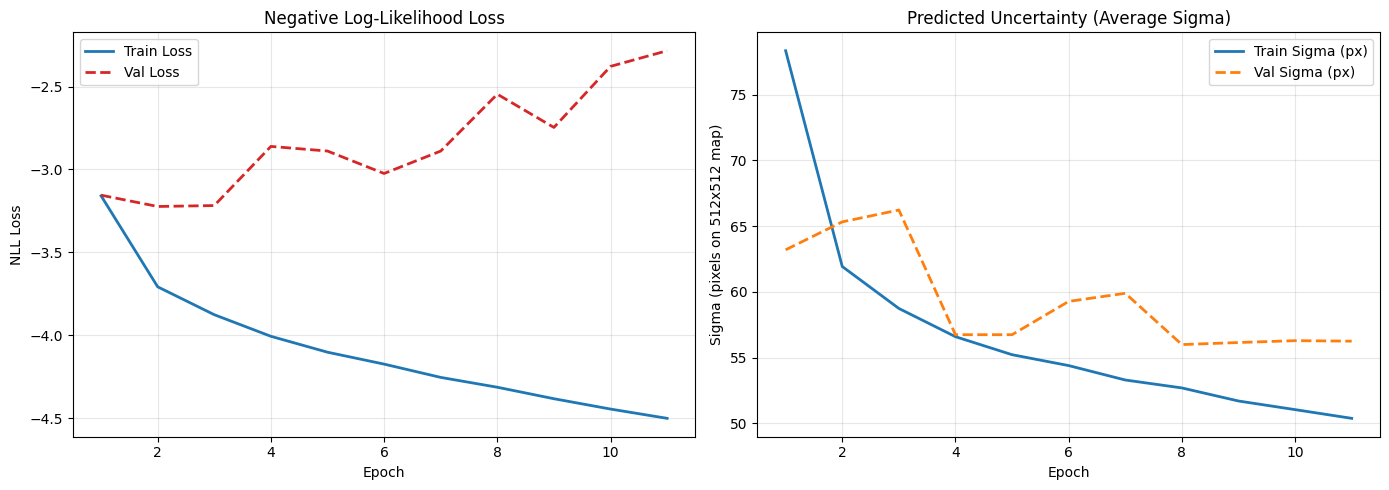

In [7]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Negative Log-Likelihood Loss
ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='tab:blue', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], label='Val Loss', color='tab:red', linestyle='--', linewidth=2)
ax1.set_title('Negative Log-Likelihood Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('NLL Loss')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Uncertainty (Avg Sigma in pixels)
ax2.plot(epochs_range, history['train_sigma'], label='Train Sigma (px)', color='tab:blue', linewidth=2)
ax2.plot(epochs_range, history['val_sigma'], label='Val Sigma (px)', color='tab:orange', linestyle='--', linewidth=2)
ax2.set_title('Predicted Uncertainty (Average Sigma)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Sigma (pixels on 512x512 map)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


Visualizing Match: SG2-171944813
Loaded best weights from models\fow_transformer_best.pt
Total testable frames: 1408 (1,348 sliding windows)


C:\Users\Aiden\AppData\Local\Temp\ipykernel_29132\3102502613.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_weights, map_location

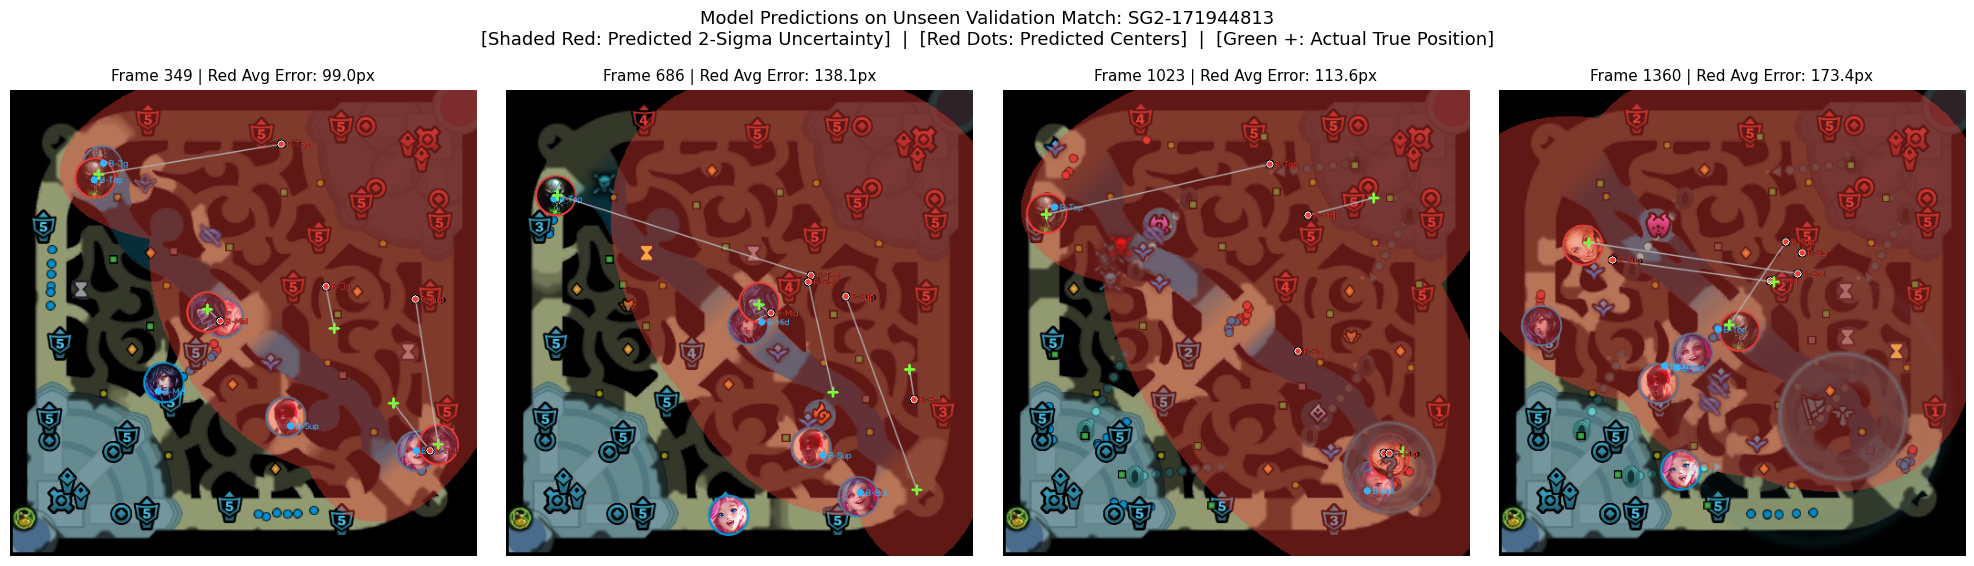


Rendering full match video to prediction_overlay_SG2-171944813.mp4...


Rendering Video: 100%|██████████| 1348/1348 [00:23<00:00, 58.49it/s]

✓ Video saved to: prediction_overlay_SG2-171944813.mp4


In [9]:
# ==============================================================================
# 8. MINIMAP PREDICTION & UNCERTAINTY VISUALIZER
# ==============================================================================
# Visualizes model predictions & Gaussian uncertainty heatmaps directly over minimap screenshots.
# - Part A: Plots inline multi-frame snapshots directly inside the notebook
# - Part B: Optional interactive OpenCV window or MP4 video export

import random
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1. Select Match & Load Best Weights ---
# Randomly select an unseen validation match (or fallback to any cleaned match)
match_pool = val_matches if ('val_matches' in globals() and len(val_matches) > 0) else cleaned_matches
selected_match = random.choice(match_pool)
match_id = selected_match.name
print(f"Visualizing Match: {match_id}")

# Load best checkpoint weights if available
best_weights = Path("models/fow_transformer_best.pt")
if best_weights.exists():
    model.load_state_dict(torch.load(best_weights, map_location=device))
    print(f"Loaded best weights from {best_weights}")
model.eval()

# --- 2. Load Trajectory Data for Selected Match ---
blue_csv = selected_match / "Blue data" / "cleaned_match_data.csv"
all_csv = selected_match / "All data" / "cleaned_match_data.csv"
screenshots_dir = selected_match / "0" / "Blue"

df_in = pd.read_csv(blue_csv)
df_targ = pd.read_csv(all_csv)

ORDERED_ROLES = [
    'Blue_Top', 'Blue_Jungle', 'Blue_Mid', 'Blue_Bot', 'Blue_Support',
    'Red_Top', 'Red_Jungle', 'Red_Mid', 'Red_Bot', 'Red_Support'
]
BLUE_ROLE_TAGS = ['B-Top', 'B-Jg', 'B-Mid', 'B-Bot', 'B-Sup']
RED_ROLE_TAGS  = ['R-Top', 'R-Jg', 'R-Mid', 'R-Bot', 'R-Sup']

# Pivot tables
pivot_in = df_in.pivot(index='frame', columns='role', values=['x', 'y', 'confidence']).reindex(
    columns=pd.MultiIndex.from_product([['x', 'y', 'confidence'], ORDERED_ROLES])
)
pivot_targ = df_targ.pivot(index='frame', columns='role', values=['x', 'y']).reindex(
    columns=pd.MultiIndex.from_product([['x', 'y'], ORDERED_ROLES])
)

common_frames = sorted(list(pivot_in.index.intersection(pivot_targ.index)))
pivot_in = pivot_in.loc[common_frames]
pivot_targ = pivot_targ.loc[common_frames]

in_tensor = torch.tensor(pivot_in.values, dtype=torch.float32)
targ_tensor = torch.tensor(np.stack([
    np.stack([pivot_targ['x'][r].values, pivot_targ['y'][r].values], axis=-1)
    for r in ORDERED_ROLES
], axis=1), dtype=torch.float32)

# Normalize
in_tensor[:, :20] = torch.where(in_tensor[:, :20] >= 0, in_tensor[:, :20] / 512.0, in_tensor[:, :20])
targ_tensor = torch.where(targ_tensor >= 0, targ_tensor / 512.0, targ_tensor)

total_windows = len(common_frames) - SEQ_LEN
print(f"Total testable frames: {len(common_frames)} ({total_windows:,} sliding windows)")


# --- 3. Rendering Helper Function ---
def render_prediction_frame(window_idx, n_std=2.0, show_gt=True):
    """
    Renders prediction ellipses and ground-truth crosshairs over the screenshot.
    Returns: frame (BGR numpy image), target_frame_num, avg_red_error_px
    """
    target_frame = common_frames[window_idx + SEQ_LEN]
    img_path = screenshots_dir / f"{target_frame}.png"

    if img_path.exists():
        frame = cv2.imread(str(img_path))
        if frame.shape[:2] != (512, 512):
            frame = cv2.resize(frame, (512, 512))
    else:
        frame = np.full((512, 512, 3), 35, dtype=np.uint8)

    overlay = frame.copy()

    # Model inference: output is (5, 5) for the 5 Red enemy roles
    x_in = in_tensor[window_idx : window_idx + SEQ_LEN].unsqueeze(0).to(device)
    with torch.no_grad():
        preds = model(x_in)[0].cpu()  # (5, 5) -> [mu_x, mu_y, sig_x, sig_y, rho]

    gt = targ_tensor[window_idx + SEQ_LEN]  # (10, 2)

    # 1. Draw 2-Sigma Gaussian Uncertainty Ellipses for Red Team
    for r_idx in range(5):
        mu_x = preds[r_idx, 0].item() * 512.0
        mu_y = preds[r_idx, 1].item() * 512.0
        sig_x = preds[r_idx, 2].item() * 512.0
        sig_y = preds[r_idx, 3].item() * 512.0
        rho = preds[r_idx, 4].item()

        cov = np.array([[sig_x**2, rho * sig_x * sig_y], [rho * sig_x * sig_y, sig_y**2]], dtype=np.float32)
        eigenvals, eigenvecs = np.linalg.eigh(cov)
        order = eigenvals.argsort()[::-1]
        eigenvals, eigenvecs = eigenvals[order], eigenvecs[:, order]

        axis_major = max(int(n_std * np.sqrt(max(eigenvals[0], 1e-4))), 4)
        axis_minor = max(int(n_std * np.sqrt(max(eigenvals[1], 1e-4))), 4)
        angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))

        cv2.ellipse(
            overlay,
            (int(np.clip(mu_x, 0, 511)), int(np.clip(mu_y, 0, 511))),
            (axis_major, axis_minor),
            angle, 0, 360,
            (50, 60, 240),  # Red tint
            -1
        )

    # Blend uncertainty heatmaps onto minimap
    cv2.addWeighted(overlay, 0.40, frame, 0.60, 0, frame)

    # 2. Draw Known Blue Team Positions from Latest Input Frame
    for b_idx in range(5):
        bx = in_tensor[window_idx + SEQ_LEN - 1, b_idx].item()
        by = in_tensor[window_idx + SEQ_LEN - 1, 10 + b_idx].item()
        if bx >= 0 and by >= 0:
            b_px = int(bx * 512.0)
            b_py = int(by * 512.0)
            cv2.circle(frame, (b_px, b_py), 4, (255, 180, 50), -1)
            cv2.putText(frame, BLUE_ROLE_TAGS[b_idx], (b_px + 6, b_py + 4), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 180, 50), 1)

    # 3. Draw Red Team Predictions, Ground Truth Crosshairs, and Error Lines
    red_errors = []
    for r_idx in range(5):
        tag = RED_ROLE_TAGS[r_idx]
        mu_x = int(np.clip(preds[r_idx, 0].item() * 512.0, 0, 511))
        mu_y = int(np.clip(preds[r_idx, 1].item() * 512.0, 0, 511))
        gt_role_idx = 5 + r_idx

        # Ground Truth Marker (Lime Green Crosshair)
        if show_gt and gt[gt_role_idx, 0] >= 0:
            gt_x = int(gt[gt_role_idx, 0].item() * 512.0)
            gt_y = int(gt[gt_role_idx, 1].item() * 512.0)
            cv2.drawMarker(frame, (gt_x, gt_y), (50, 255, 120), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)

            dist = np.hypot(mu_x - gt_x, mu_y - gt_y)
            red_errors.append(dist)
            # Thin line from predicted center to true position
            cv2.line(frame, (mu_x, mu_y), (gt_x, gt_y), (180, 180, 180), 1, cv2.LINE_AA)

        # Predicted Center Dot
        cv2.circle(frame, (mu_x, mu_y), 5, (0, 0, 0), -1)
        cv2.circle(frame, (mu_x, mu_y), 4, (50, 60, 240), -1)
        cv2.circle(frame, (mu_x, mu_y), 4, (255, 255, 255), 1)
        cv2.putText(frame, tag, (mu_x + 6, mu_y + 4), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 0, 0), 2)
        cv2.putText(frame, tag, (mu_x + 6, mu_y + 4), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (50, 60, 240), 1)

    avg_err = np.mean(red_errors) if red_errors else 0.0
    return frame, target_frame, avg_err


# --- 4. PART A: Inline Matplotlib Snapshots (Directly in Notebook) ---
sample_indices = [
    int(total_windows * 0.15),
    int(total_windows * 0.40),
    int(total_windows * 0.65),
    int(total_windows * 0.90)
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
for ax, s_idx in zip(axes, sample_indices):
    rendered_bgr, f_num, err_px = render_prediction_frame(s_idx, n_std=2.0, show_gt=True)
    rendered_rgb = cv2.cvtColor(rendered_bgr, cv2.COLOR_BGR2RGB)
    
    ax.imshow(rendered_rgb)
    ax.set_title(f"Frame {f_num} | Red Avg Error: {err_px:.1f}px", fontsize=11)
    ax.axis("off")

plt.suptitle(
    f"Model Predictions on Unseen Validation Match: {match_id}\n"
    "[Shaded Red: Predicted 2-Sigma Uncertainty]  |  [Red Dots: Predicted Centers]  |  [Green +: Actual True Position]",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()


# --- 5. PART B: Optional Video Export or Desktop Interactive Window ---
# Set EXPORT_VIDEO = True to render a high-fps .mp4 replay of the entire match!
EXPORT_VIDEO = True
output_video_path = f"prediction_overlay_{match_id}.mp4"

if EXPORT_VIDEO:
    print(f"\nRendering full match video to {output_video_path}...")
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_video_path, fourcc, 25.0, (512, 512))
    
    for idx in tqdm(range(total_windows), desc="Rendering Video"):
        frame_bgr, _, _ = render_prediction_frame(idx, n_std=2.0, show_gt=True)
        writer.write(frame_bgr)
        
    writer.release()
    print(f"✓ Video saved to: {output_video_path}")
